# Financial Performance Prediction
# 金融绩效预测

预测上市公司最近季度(Q0)的9个财务指标，使用前10个季度的历史数据和公司元信息作为特征。

评估指标: R2 Score (各目标R2取平均)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

## 1. 数据加载与初步探索

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print('训练集:', train.shape)
print('测试集:', test.shape)

训练集: (1624, 212)
测试集: (406, 203)


In [3]:
# 9个预测目标
targets = ['Q0_TOTAL_ASSETS', 'Q0_TOTAL_LIABILITIES', 'Q0_TOTAL_STOCKHOLDERS_EQUITY',
           'Q0_GROSS_PROFIT', 'Q0_COST_OF_REVENUES', 'Q0_REVENUES',
           'Q0_OPERATING_INCOME', 'Q0_OPERATING_EXPENSES', 'Q0_EBITDA']

print('目标列统计:')
train[targets].describe()

目标列统计:


,Q0_TOTAL_ASSETS,Q0_TOTAL_LIABILITIES,Q0_TOTAL_STOCKHOLDERS_EQUITY,Q0_GROSS_PROFIT,Q0_COST_OF_REVENUES,Q0_REVENUES,Q0_OPERATING_INCOME,Q0_OPERATING_EXPENSES,Q0_EBITDA
count,1.624000e+03,1.624000e+03,1.624000e+03,1.624000e+03,1.624000e+03,1.624000e+03,1.624000e+03,1.624000e+03,1.624000e+03
mean,4.797691e+09,3.200071e+09,1.289882e+09,4.240823e+08,6.584900e+08,1.062931e+09,9.842535e+07,3.557741e+08,6.830815e+07
std,2.636638e+10,1.624373e+10,1.169109e+10,1.817923e+09,3.085667e+09,4.041767e+09,6.310543e+08,1.553039e+09,1.438216e+09
min,-1.953310e+11,-1.399650e+11,-9.784800e+10,-9.170000e+08,-1.587300e+10,-3.850000e+08,-2.654000e+09,-2.403000e+07,-3.282900e+10
25%,9.808875e+07,3.658962e+07,1.765381e+07,2.289663e+06,6.294782e+05,6.687640e+06,-1.113500e+07,1.159175e+07,-1.493733e+07
50%,6.317055e+08,2.916500e+08,2.470010e+08,3.755700e+07,2.513599e+07,9.266800e+07,-2.001465e+05,4.614450e+07,-7.000000e+05
75%,2.708209e+09,1.613343e+09,1.031333e+09,2.074888e+08,2.579560e+08,5.159818e+08,4.105925e+07,1.805822e+08,3.605775e+07
max,3.848300e+11,2.127170e+11,1.807181e+11,3.718600e+10,5.074900e+10,4.904800e+10,1.374800e+10,4.111800e+10,3.413800e+10


In [4]:
# 缺失值情况
missing_pct = train.isnull().sum() / len(train) * 100
print(f'有缺失值的列: {(missing_pct > 0).sum()} / {len(train.columns)}')
print()
# 缺失比例超过50%的列
high_missing = missing_pct[missing_pct > 50]
print(f'缺失>50%的列({len(high_missing)}个):')
print(high_missing.sort_values(ascending=False).head(10))

有缺失值的列: 186 / 212

缺失>50%的列(1个):
trailingPE    55.541872
dtype: float64


In [5]:
# 类别列
cat_cols = ['industry', 'sector', 'recommendationKey', 'financialCurrency']
for c in cat_cols:
    print(f'{c}: {train[c].nunique()} unique values')
print()
print(train['sector'].value_counts())

industry: 113 unique values
sector: 10 unique values
recommendationKey: 6 unique values
financialCurrency: 2 unique values

sector
Healthcare                485
Technology                303
Industrials               242
Consumer Cyclical         209
Energy                     91
Communication Services     87
Consumer Defensive         86
Basic Materials            72
Utilities                  27
Unknown                    22
Name: count, dtype: int64


## 2. 数据探索与可视化

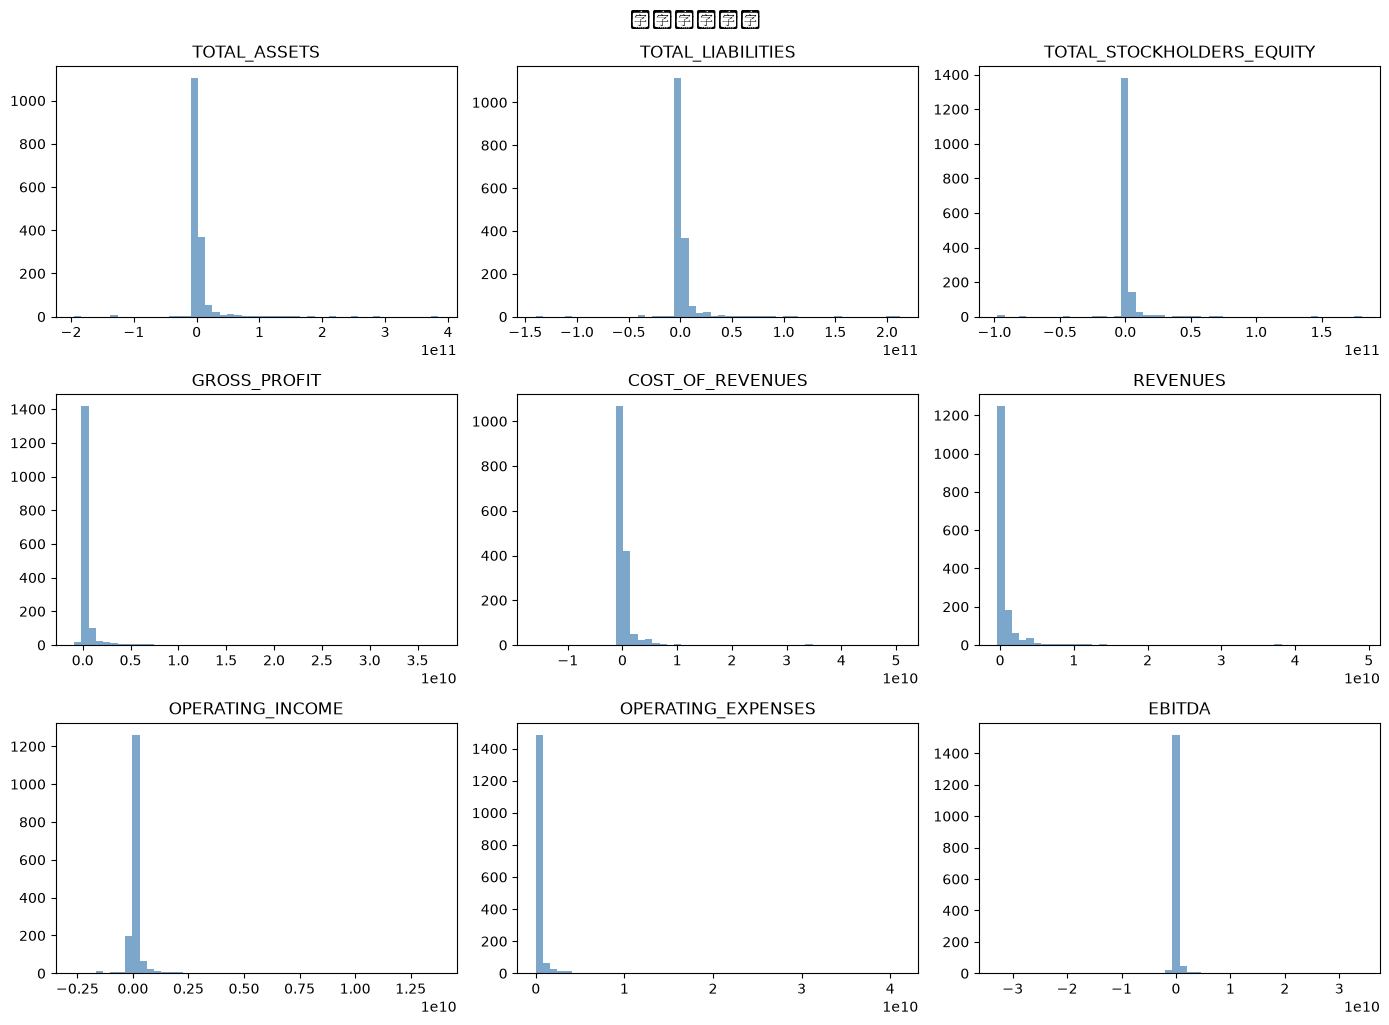

In [6]:
# 目标变量分布
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for i, col in enumerate(targets):
    ax = axes[i // 3, i % 3]
    ax.hist(train[col].dropna(), bins=50, color='steelblue', alpha=0.7)
    ax.set_title(col.replace('Q0_', ''))
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.tight_layout()
plt.suptitle('目标变量分布', y=1.02, fontsize=14)
plt.show()

In [7]:
# Q1各指标和Q0目标的相关性（最直接的时序关系）
q1_to_q0_map = {
    'Q1_TOTAL_ASSETS': 'Q0_TOTAL_ASSETS',
    'Q1_TOTAL_LIABILITIES': 'Q0_TOTAL_LIABILITIES',
    'Q1_TOTAL_STOCKHOLDERS_EQUITY': 'Q0_TOTAL_STOCKHOLDERS_EQUITY',
    'Q1_GROSS_PROFIT': 'Q0_GROSS_PROFIT',
    'Q1_COST_OF_REVENUES': 'Q0_COST_OF_REVENUES',
    'Q1_REVENUES': 'Q0_REVENUES',
    'Q1_OPERATING_INCOME': 'Q0_OPERATING_INCOME',
    'Q1_OPERATING_EXPENSES': 'Q0_OPERATING_EXPENSES',
    'Q1_EBITDA': 'Q0_EBITDA'
}
print('Q1 vs Q0 相关系数（同名指标）:')
for q1, q0 in q1_to_q0_map.items():
    corr = train[q1].corr(train[q0])
    print(f'  {q1} -> {q0}: {corr:.4f}')

Q1 vs Q0 相关系数（同名指标）:
  Q1_TOTAL_ASSETS -> Q0_TOTAL_ASSETS: 0.6599
  Q1_TOTAL_LIABILITIES -> Q0_TOTAL_LIABILITIES: 0.8126
  Q1_TOTAL_STOCKHOLDERS_EQUITY -> Q0_TOTAL_STOCKHOLDERS_EQUITY: 0.3083
  Q1_GROSS_PROFIT -> Q0_GROSS_PROFIT: 0.9920
  Q1_COST_OF_REVENUES -> Q0_COST_OF_REVENUES: 0.9826
  Q1_REVENUES -> Q0_REVENUES: 0.9871
  Q1_OPERATING_INCOME -> Q0_OPERATING_INCOME: 0.8861
  Q1_OPERATING_EXPENSES -> Q0_OPERATING_EXPENSES: 0.9916
  Q1_EBITDA -> Q0_EBITDA: 0.9795


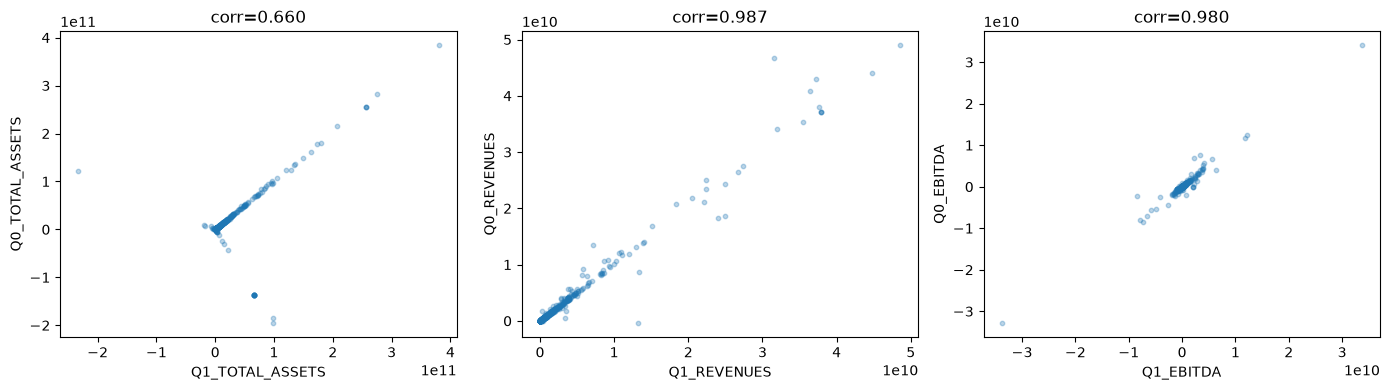

In [8]:
# 画Q1 vs Q0的散点图（选3个代表性的）
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [('Q1_TOTAL_ASSETS', 'Q0_TOTAL_ASSETS'),
         ('Q1_REVENUES', 'Q0_REVENUES'),
         ('Q1_EBITDA', 'Q0_EBITDA')]
for ax, (q1, q0) in zip(axes, pairs):
    ax.scatter(train[q1], train[q0], alpha=0.3, s=10)
    ax.set_xlabel(q1)
    ax.set_ylabel(q0)
    ax.set_title(f'corr={train[q1].corr(train[q0]):.3f}')
plt.tight_layout()
plt.show()

## 3. 数据预处理

In [9]:
# 分离目标和特征
y_train = train[targets].copy()
drop_cols = targets + ['Q0_fiscal_year_end', 'Id']
X_train = train.drop(columns=[c for c in drop_cols if c in train.columns]).copy()
X_test = test.drop(columns=[c for c in ['Id', 'Q0_fiscal_year_end'] if c in test.columns]).copy()

# 类别列编码
cat_cols = ['industry', 'sector', 'recommendationKey', 'financialCurrency']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([X_train[col], X_test[col]]).fillna('Unknown')
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].fillna('Unknown'))
    X_test[col] = le.transform(X_test[col].fillna('Unknown'))
    le_dict[col] = le

# 替换inf为nan，然后统一填充中位数
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

num_cols = X_train.select_dtypes(include=[np.number]).columns
for col in num_cols:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

# 确保列对齐
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print('特征矩阵:', X_train.shape, X_test.shape)
print('缺失值检查:', X_train.isnull().sum().sum(), X_test.isnull().sum().sum())
print('Inf检查:', np.isinf(X_train.values).sum(), np.isinf(X_test.values).sum())

特征矩阵: (1624, 201) (406, 201)
缺失值检查: 0 0
Inf检查: 0 0


## 4. 模型训练与交叉验证

In [10]:
# 对每个目标分别训练GBDT
models = {}
cv_scores = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for target in targets:
    gb = GradientBoostingRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    )
    
    # 交叉验证
    scores = cross_val_score(gb, X_train, y_train[target], cv=kf, scoring='r2')
    cv_scores[target] = scores
    
    # 全量训练
    gb.fit(X_train, y_train[target])
    models[target] = gb
    
    print(f'{target.replace("Q0_", ""):30s} CV R2: {scores.mean():.4f} (+/- {scores.std():.4f})')

avg_r2 = np.mean([s.mean() for s in cv_scores.values()])
print(f'\n平均CV R2: {avg_r2:.4f}')

TOTAL_ASSETS                   CV R2: 0.7992 (+/- 0.1826)


TOTAL_LIABILITIES              CV R2: 0.8297 (+/- 0.2166)


TOTAL_STOCKHOLDERS_EQUITY      CV R2: 0.7792 (+/- 0.1741)


GROSS_PROFIT                   CV R2: 0.9133 (+/- 0.0639)


COST_OF_REVENUES               CV R2: 0.9138 (+/- 0.1108)


REVENUES                       CV R2: 0.9389 (+/- 0.0836)


OPERATING_INCOME               CV R2: 0.7641 (+/- 0.1267)


OPERATING_EXPENSES             CV R2: 0.8942 (+/- 0.1040)


EBITDA                         CV R2: 0.5956 (+/- 0.3293)

平均CV R2: 0.8253


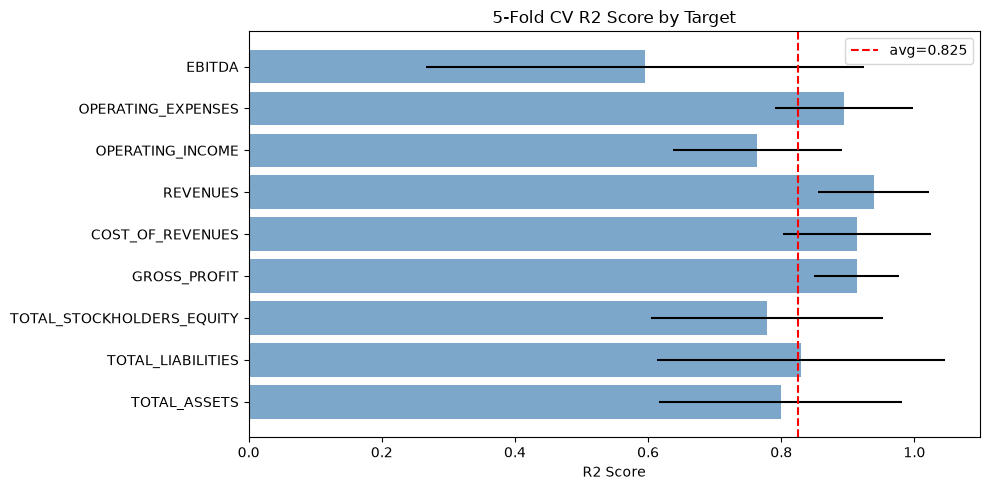

In [11]:
# 交叉验证结果可视化
fig, ax = plt.subplots(figsize=(10, 5))
names = [t.replace('Q0_', '') for t in targets]
means = [cv_scores[t].mean() for t in targets]
stds = [cv_scores[t].std() for t in targets]
ax.barh(names, means, xerr=stds, color='steelblue', alpha=0.7)
ax.set_xlabel('R2 Score')
ax.set_title('5-Fold CV R2 Score by Target')
ax.axvline(avg_r2, color='red', linestyle='--', label=f'avg={avg_r2:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

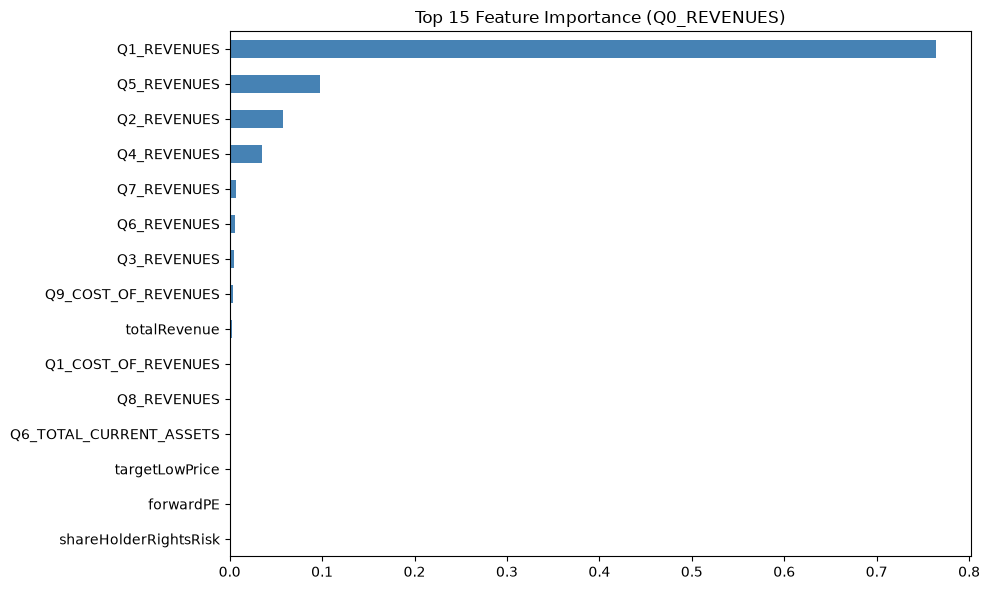

In [12]:
# 特征重要性 (以REVENUES为例)
importances = models['Q0_REVENUES'].feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Feature Importance (Q0_REVENUES)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. 预测与提交

In [13]:
# 在测试集上预测
submission = pd.DataFrame({'Id': test['Id']})
for target in targets:
    submission[target] = models[target].predict(X_test)

submission.to_csv('submission.csv', index=False)
print('submission.csv 已生成')
print(submission.head())

submission.csv 已生成
     Id  Q0_TOTAL_ASSETS  Q0_TOTAL_LIABILITIES  Q0_TOTAL_STOCKHOLDERS_EQUITY  \
0   480     2.870746e+07          1.928645e+07                  7.994771e+06   
1   573     3.995363e+09          2.709087e+09                  4.081520e+08   
2  1967     1.033993e+08          2.992273e+07                 -7.098730e+05   
3    57     5.613359e+09          2.108028e+09                  3.342316e+09   
4   131     4.541393e+09          3.302263e+09                  1.124848e+09   

   Q0_GROSS_PROFIT  Q0_COST_OF_REVENUES   Q0_REVENUES  Q0_OPERATING_INCOME  \
0    -2.498250e+05         4.660169e+05  1.557659e+05        -1.263540e+06   
1     2.106353e+08         3.609216e+08  6.032008e+08         3.246635e+07   
2    -2.736387e+05         2.553158e+07  2.125209e+07        -5.908380e+06   
3     1.730175e+08         2.542069e+08  5.315802e+08         6.147587e+07   
4     1.978069e+08         8.344377e+08  9.863421e+08         1.051455e+08   

   Q0_OPERATING_EXPENSES     Q0

In [14]:
# 训练集上的拟合情况
print('训练集 R2:')
for target in targets:
    pred = models[target].predict(X_train)
    r2 = r2_score(y_train[target], pred)
    print(f'  {target.replace("Q0_", ""):30s} R2: {r2:.4f}')

训练集 R2:
  TOTAL_ASSETS                   R2: 1.0000
  TOTAL_LIABILITIES              R2: 1.0000
  TOTAL_STOCKHOLDERS_EQUITY      R2: 0.9999
  GROSS_PROFIT                   R2: 0.9999
  COST_OF_REVENUES               R2: 1.0000
  REVENUES                       R2: 1.0000
  OPERATING_INCOME               R2: 0.9992
  OPERATING_EXPENSES             R2: 0.9999
  EBITDA                         R2: 0.9998
